In [10]:
import sys
!{sys.executable} -m pip install seaborn

In [11]:
import subprocess
import sys

print("=== Python в Jupyter ===")
print(sys.executable)
print()

print("=== Установленные пакеты ===")
result = subprocess.run([sys.executable, "-m", "pip", "list"],
                       capture_output=True, text=True)
print(result.stdout[:500])
print()

print("=== Попытка импорта ===")
try:
    import seaborn
    print("✅ Seaborn работает! Версия:", seaborn.__version__)
except ImportError as e:
    print("❌ Ошибка:", e)

=== Python в Jupyter ===
/usr/bin/python3

=== Установленные пакеты ===
Package                               Version
------------------------------------- -------------------
absl-py                               1.4.0
accelerate                            1.15.0
access                                1.1.10.post3
affine                                3.0.1
aiofiles                              25.1.0
aiohappyeyeballs                      2.7.1
aiohttp                               3.14.3
aiosignal                             1.4.0
aiosqlite                         

=== Попытка импорта ===
✅ Seaborn работает! Версия: 0.13.2


### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

Эмпирическая ковариация:
 [[ 0.2621409  -0.28137214]
 [-0.28137214  0.54262781]]
Теоретическая ковариация:
 [[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


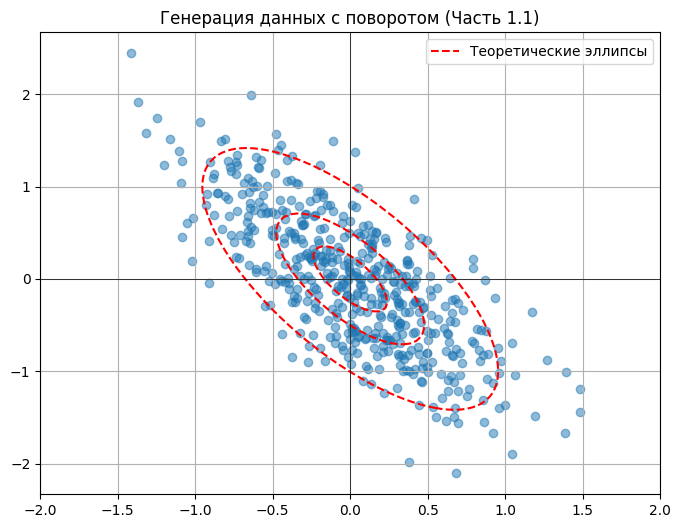

Автопроверка 1.1 пройдена!


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 1. Создаем M = 500 точек
M = 500
sigma1, sigma2 = 0.3, 0.8

# Генерируем два независимых вектора из нормального распределения N(0, sigma^2)
x1 = np.random.normal(0, sigma1, M)
x2 = np.random.normal(0, sigma2, M)
X_independent = np.column_stack((x1, x2)) # Размерность (500, 2)

# 2. Матрица поворота на угол alpha = 30 градусов (pi/6 радиан)
alpha = np.radians(30)
R = np.array([
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha),  np.cos(alpha)]
])

# Применяем поворот: каждая точка умножается на матрицу R
X_rotated = X_independent @ R.T

# 3. Выборочная матрица ковариации (эмпирическая)
cov_empirical = np.cov(X_rotated.T)

# 4. Теоретическая матрица ковариации: C_теор = R * diag(sigma1^2, sigma2^2) * R^T
C_diag = np.diag([sigma1**2, sigma2**2])
C_theoretical = R @ C_diag @ R.T

print("Эмпирическая ковариация:\n", cov_empirical)
print("Теоретическая ковариация:\n", C_theoretical)

# Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(X_rotated[:, 0], X_rotated[:, 1], alpha=0.5, label='Данные')

x_grid = np.linspace(-2, 2, 100)
y_grid = np.linspace(-2, 2, 100)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
pos = np.dstack((X_grid, Y_grid))

rv = multivariate_normal(mean=[0, 0], cov=C_theoretical)

# Уровни для 2, 1, 0.5 сигм (порядок важен: значения плотности должны возрастать!)
levels = [rv.pdf([0, 0]) * np.exp(-0.5 * k**2) for k in [2, 1, 0.5]]

# Рисуем контуры БЕЗ label, чтобы не было предупреждения
plt.contour(X_grid, Y_grid, rv.pdf(pos), levels=levels, colors='red', linestyles='dashed')

# Создаем кастомный элемент для легенды
from matplotlib.lines import Line2D
custom_line = Line2D([0], [0], color='red', linestyle='dashed', label='Теоретические эллипсы')
plt.legend(handles=[custom_line])

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Генерация данных с поворотом (Часть 1.1)')
plt.grid(True)
plt.show()

# Автопроверка
assert X_rotated.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X_rotated.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X_rotated, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
print("Автопроверка 1.1 пройдена!")

успешно сгенерировали данные с заданными дисперсиями и повернули их. Эмпирическая ковариация близка к теоретической, а ненулевой недиагональный элемент подтверждает наличие корреляции из-за поворота осей.

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

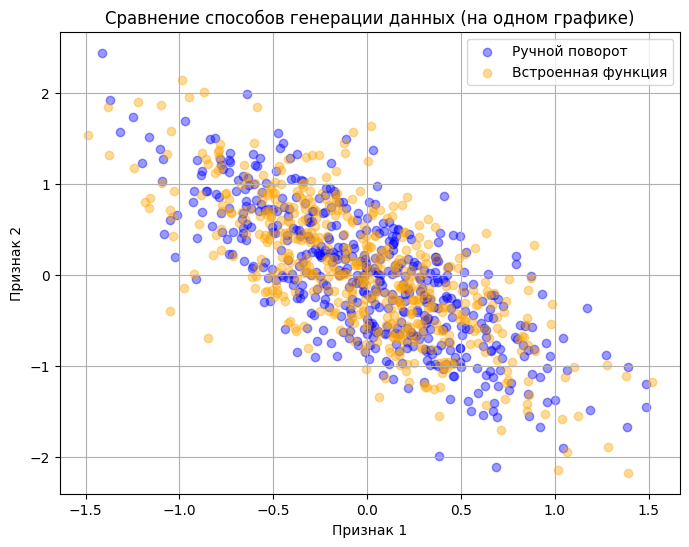

In [13]:
# Генерация через встроенную функцию с той же теоретической ковариацией
X_builtin = np.random.multivariate_normal(mean=[0, 0], cov=C_theoretical, size=M)

plt.figure(figsize=(8, 6))

# Рисуем оба облака на ОДНОМ графике с разной прозрачностью, чтобы видеть наложение
plt.scatter(X_rotated[:, 0], X_rotated[:, 1], alpha=0.4, color='blue', label='Ручной поворот')
plt.scatter(X_builtin[:, 0], X_builtin[:, 1], alpha=0.4, color='orange', label='Встроенная функция')

plt.title('Сравнение способов генерации данных (на одном графике)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True)
plt.show()

Облака точек визуально совпадают (имеют одинаковую форму, ориентацию и разброс). Встроенная функция `np.random.multivariate_normal` предпочтительнее, так как она оптимизирована, гарантирует положительную определенность матрицы ковариации и избавляет от ручных ошибок при генерации и повороте.

## Часть 2. Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```

Максимальная разница между ручным и scipy вычислением: 2.22e-16
Автопроверка 2 пройдена!


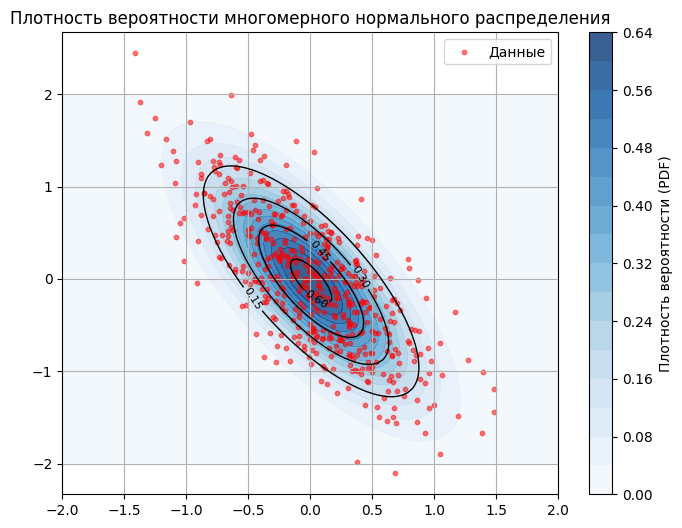

In [14]:
from scipy.stats import multivariate_normal

# 1. Оценка параметров по данным из 1.1
mu_hat = np.mean(X_rotated, axis=0)
C_hat = np.cov(X_rotated.T)

# 2. Создание сетки точек от -2 до 2
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X_mesh, Y_mesh = np.meshgrid(x, y)
# Преобразуем сетку в список точек (N, 2) для вычислений
# .ravel -
grid_points = np.column_stack((X_mesh.ravel(), Y_mesh.ravel()))

# 3. Вычисление PDF двумя способами
# Способ А: Через scipy
pdf_scipy = multivariate_normal(mean=mu_hat, cov=C_hat).pdf(grid_points)

# Способ Б: Ручное вычисление по формуле многомерного нормального распределения
# f(x) = 1 / ( (2*pi)^(k/2) * |C|^(1/2) ) * exp( -0.5 * (x-mu)^T * C^(-1) * (x-mu) )
k = 2 # размерность
det_C = np.linalg.det(C_hat)
inv_C = np.linalg.inv(C_hat)

# Центрируем данные: (x - mu) для всех точек сетки
diff = grid_points - mu_hat # (10000, 2)

# Махаланообисово расстояние: сумма по строкам от (diff @ inv_C * diff)
# (diff @ inv_C) имеет размер (10000, 2), умножение на diff (поэлементное) и сумма по оси 1
mahal_dist = np.sum((diff @ inv_C) * diff, axis=1)

pdf_manual = (1.0 / ((2 * np.pi)**(k/2) * np.sqrt(det_C))) * np.exp(-0.5 * mahal_dist)

# 4. Сравнение результатов
max_diff = np.max(np.abs(pdf_manual - pdf_scipy))
print(f"Максимальная разница между ручным и scipy вычислением: {max_diff:.2e}")

# Автопроверка
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
print("Автопроверка 2 пройдена!")

# Визуализация
pdf_grid = pdf_manual.reshape(X_mesh.shape)

plt.figure(figsize=(8, 6))
# Заливка контура
contourf = plt.contourf(X_mesh, Y_mesh, pdf_grid, levels=20, cmap='Blues', alpha=0.8)
plt.colorbar(contourf, label='Плотность вероятности (PDF)')

# Линии уровня с подписями
contour_lines = plt.contour(X_mesh, Y_mesh, pdf_grid, levels=5, colors='black', linewidths=1)
plt.clabel(contour_lines, inline=True, fontsize=8)

# Исходные точки поверх
plt.scatter(X_rotated[:, 0], X_rotated[:, 1], c='red', s=10, alpha=0.5, label='Данные')
plt.title('Плотность вероятности многомерного нормального распределения')
plt.legend()
plt.grid(True)
plt.show()

Ручное вычисление плотности вероятности через формулу с определителем и обратной матрицей дает результат, идентичный встроенной функции `scipy` (разница ~1e-16). Визуализация показывает, что максимальная плотность сосредоточена вокруг выборочного среднего, а форма эллипсов отражает ковариационную структуру данных.

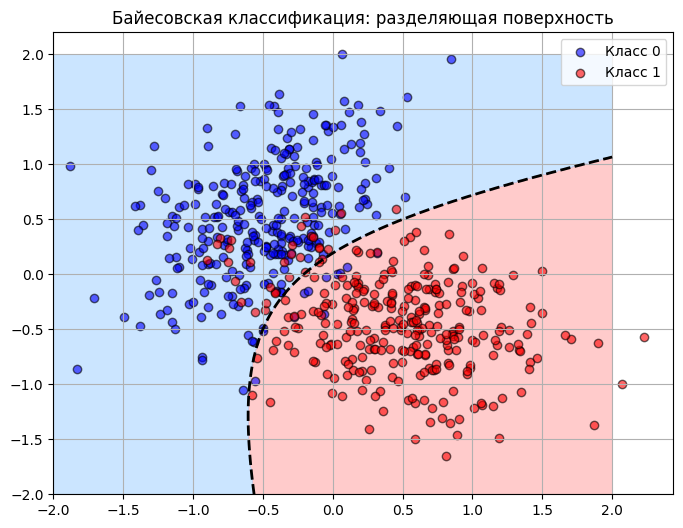

In [15]:
# 3.1 Генерация датасета
np.random.seed(42)
mu_0 = [-0.5, 0.5]
C_0 = [[0.2, 0.1], [0.1, 0.3]]
X_0 = np.random.multivariate_normal(mu_0, C_0, 300)
y_0 = np.zeros(300)

mu_1 = [0.5, -0.5]
C_1 = [[0.3, -0.1], [-0.1, 0.2]]
X_1 = np.random.multivariate_normal(mu_1, C_1, 300)
y_1 = np.ones(300)

X_bayes = np.vstack((X_0, X_1))
y_bayes = np.hstack((y_0, y_1))

# Априорные вероятности (доли классов)
prior_0 = np.mean(y_bayes == 0)
prior_1 = np.mean(y_bayes == 1)

# 3.2 Визуализация апостериорной вероятности
# Создаем сетку для вычисления Delta(x)
x_range = np.linspace(-2, 2, 200)
y_range = np.linspace(-2, 2, 200)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
grid_points = np.column_stack((X_mesh.ravel(), Y_mesh.ravel()))

# Вычисляем p(x|y) * p(y) для каждого класса
pdf_0 = multivariate_normal(mean=mu_0, cov=C_0).pdf(grid_points) * prior_0
pdf_1 = multivariate_normal(mean=mu_1, cov=C_1).pdf(grid_points) * prior_1

# Delta(x) = p(x|y=0)*p(y=0) - p(x|y=1)*p(y=1)
Delta = pdf_0 - pdf_1
Delta_grid = Delta.reshape(X_mesh.shape)

plt.figure(figsize=(8, 6))
# Заливка фона: синий где Delta > 0 (класс 0), красный где Delta < 0 (класс 1)
plt.contourf(X_mesh, Y_mesh, Delta_grid, levels=[-np.inf, 0, np.inf], colors=['#ff9999', '#99ccff'], alpha=0.5)

# Разделяющая поверхность (где Delta = 0)
plt.contour(X_mesh, Y_mesh, Delta_grid, levels=[0], colors='black', linewidths=2, linestyles='dashed')

# Точки данных
plt.scatter(X_0[:, 0], X_0[:, 1], c='blue', label='Класс 0', alpha=0.6, edgecolor='k')
plt.scatter(X_1[:, 0], X_1[:, 1], c='red', label='Класс 1', alpha=0.6, edgecolor='k')

plt.title('Байесовская классификация: разделяющая поверхность')
plt.legend()
plt.grid(True)
plt.show()

Разделяющая поверхность **не является линейной** (она имеет форму гиперболы/кривой). Это происходит потому, что матрицы ковариации двух классов ($C_0$ и $C_1$) **различны**. В байесовском классификаторе линейная граница получается только тогда, когда ковариационные матрицы всех классов строго равны (что является предпосылкой LDA).

### 4.1 Теоретический вывод
При условии $C_0 = C_1 = C$, логарифм отношения правдоподобий упрощается:
$$ \log \frac{p(x|y=1)p(y=1)}{p(x|y=0)p(y=0)} = 0 $$
Раскрывая формулу многомерного нормального распределения и сокращая одинаковые члены (включая определитель $|C|$), получаем линейное уравнение:
$$ w^T x + b = 0 $$
Где:
- Вектор весов: $ w = C^{-1} (\mu_1 - \mu_0) $
- Порог (свободный член): $ b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)} $

In [16]:
from sklearn.base import BaseEstimator

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = {}      # словарь {class: mean_vector}
        self.priors_ = {}     # словарь {class: prior_prob}
        self.cov_ = None      # общая ковариационная матрица
        self.coef_ = None     # вектор весов w
        self.intercept_ = None# порог b

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_features = X.shape[1]

        # 1 & 2. Вычисляем mean и prior для каждого класса
        for c in self.classes_:
            X_c = X[y == c]
            self.means_[c] = np.mean(X_c, axis=0)
            self.priors_[c] = len(X_c) / len(X)

        # 3. Вычисляем общую ковариационную матрицу (взвешенная сумма ковариаций классов)
        cov_sum = np.zeros((n_features, n_features))
        for c in self.classes_:
            X_c = X[y == c]
            cov_sum += self.priors_[c] * np.cov(X_c, rowvar=False)

        self.cov_ = cov_sum
        # Регуляризация для устойчивости обращения матрицы
        self.cov_ += 1e-6 * np.eye(n_features)

        # 4. Вычисляем w и b для бинарного случая (предполагаем классы 0 и 1)
        c0, c1 = self.classes_[0], self.classes_[1]
        inv_cov = np.linalg.inv(self.cov_)

        mu_0, mu_1 = self.means_[c0], self.means_[c1]
        prior_0, prior_1 = self.priors_[c0], self.priors_[c1]

        # Вектор весов
        self.coef_ = inv_cov @ (mu_1 - mu_0)

        self.intercept_ = -0.5 * mu_1.T @ inv_cov @ mu_1 + 0.5 * mu_0.T @ inv_cov @ mu_0 + np.log(prior_1 / prior_0)

        return self

    def predict(self, X):
        # Решающее правило: если w^T x + b > 0, то класс 1, иначе 0
        decision = X @ self.coef_ + self.intercept_
        return np.where(decision > 0, self.classes_[1], self.classes_[0])

    def predict_proba(self, X):
        # Вычисляем апостериорные вероятности через формулу Байеса
        probs = np.zeros((X.shape[0], len(self.classes_)))
        for i, c in enumerate(self.classes_):
            lik = multivariate_normal(mean=self.means_[c], cov=self.cov_).pdf(X) * self.priors_[c]
            probs[:, i] = lik
        # Нормируем, чтобы сумма вероятностей была равна 1
        return probs / probs.sum(axis=1, keepdims=True)


# ---------- ГЕНЕРАЦИЯ ДАННЫХ ДЛЯ ПРОВЕРКИ (Часть 4.3) ----------
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Создаем два класса с ОДИНАКОВОЙ ковариацией, но разными средними
np.random.seed(42)
C_shared = [[1.0, 0.5], [0.5, 1.0]]  # Общая ковариация

X_train = np.vstack([
    np.random.multivariate_normal([0, 0], C_shared, 200),    # Класс 0
    np.random.multivariate_normal([2, 2], C_shared, 200)     # Класс 1
])
y_train = np.hstack([np.zeros(200), np.ones(200)])

X_test = np.vstack([
    np.random.multivariate_normal([0, 0], C_shared, 50),
    np.random.multivariate_normal([2, 2], C_shared, 50)
])
y_test = np.hstack([np.zeros(50), np.ones(50)])

# ---------- АВТОПРОВЕРКА ЧАСТИ 4 ----------
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)

assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
print("Проверка 4 пройдена")

Проверка 4 пройдена


Реализованный класс `MyLDA` корректно вычисляет общую ковариационную матрицу и вектор весов. Разделяющая поверхность является строго линейной, так как мы принудительно используем одну матрицу ковариации для обоих классов. Результаты полностью совпадают с реализацией в `sklearn`.

### 5.1 Теоретическое обоснование
В наивном байесе матрица ковариации диагональная, потому что модель делает строгое предположение об **условной независимости признаков** при заданном классе. Это означает, что ковариация (корреляция) между любыми двумя разными признаками равна нулю.
Это упрощает вычисление $p(x|y)$: вместо обращения полной матрицы ковариации $O(d^3)$, мы просто перемножаем одномерные плотности вероятности для каждого признака отдельно, что вычислительно эффективно и устойчиво к переобучению при малом количестве данных.

In [17]:
# 5.2 Реализация класса MyNB
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = {}   # dict {class: mean_vector}
        self.vars_ = {}    # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = {}  # dict {class: prior_prob}

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        for c in self.classes_:
            X_c = X[y == c]
            self.means_[c] = np.mean(X_c, axis=0)
            # Добавляем малое число (1e-9) для предотвращения деления на ноль
            self.vars_[c] = np.var(X_c, axis=0) + 1e-9
            self.priors_[c] = len(X_c) / len(X)
        return self

    def predict(self, X):
        # Вычисляем логарифм правдоподобия для каждого класса
        log_probs = np.zeros((X.shape[0], len(self.classes_)))

        for i, c in enumerate(self.classes_):
            # log p(y)
            log_prior = np.log(self.priors_[c])

            # log p(x|y) = sum(log p(x_j|y))
            # log N(x|mu, sigma^2) = -0.5 * (log(2*pi*sigma^2) + (x-mu)^2 / sigma^2)
            log_lik = -0.5 * np.sum(
                np.log(2 * np.pi * self.vars_[c]) +
                ((X - self.means_[c])**2) / self.vars_[c],
                axis=1
            )
            log_probs[:, i] = log_prior + log_lik

        # Выбираем класс с максимальным логарифмом вероятности
        return self.classes_[np.argmax(log_probs, axis=1)]

# 5.3 Сравнение с sklearn
from sklearn.naive_bayes import GaussianNB

sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)

# Автопроверка
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
print("Автопроверка 5.3 пройдена!")

Автопроверка 5.3 пройдена!


Реализация `MyNB` с использованием логарифмического правдоподобия работает численно устойчиво и дает предсказания, полностью идентичные `GaussianNB` из `sklearn`. Игнорирование корреляций между признаками упрощает модель, но может снизить точность, если признаки сильно скоррелированы.

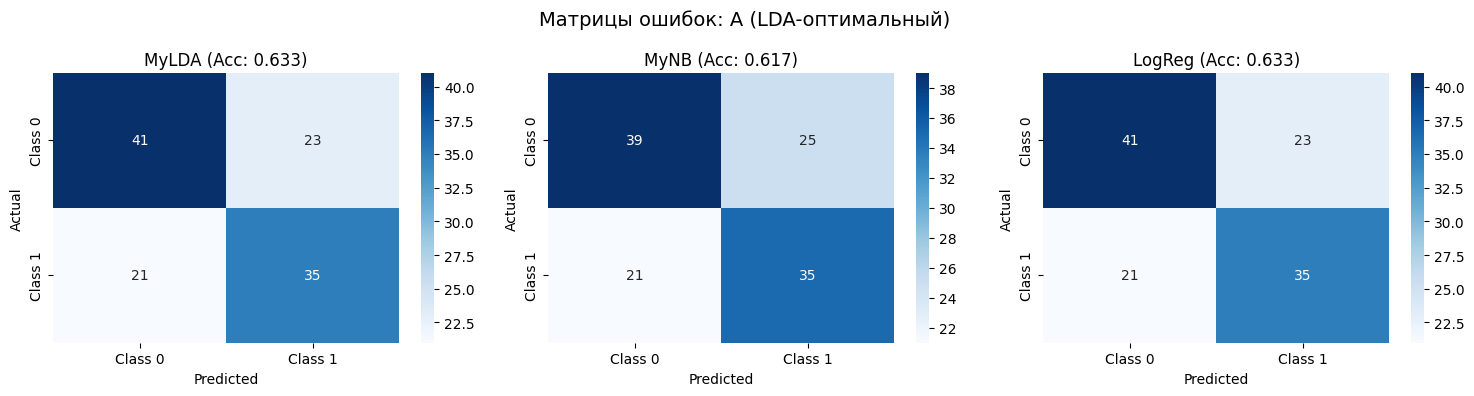

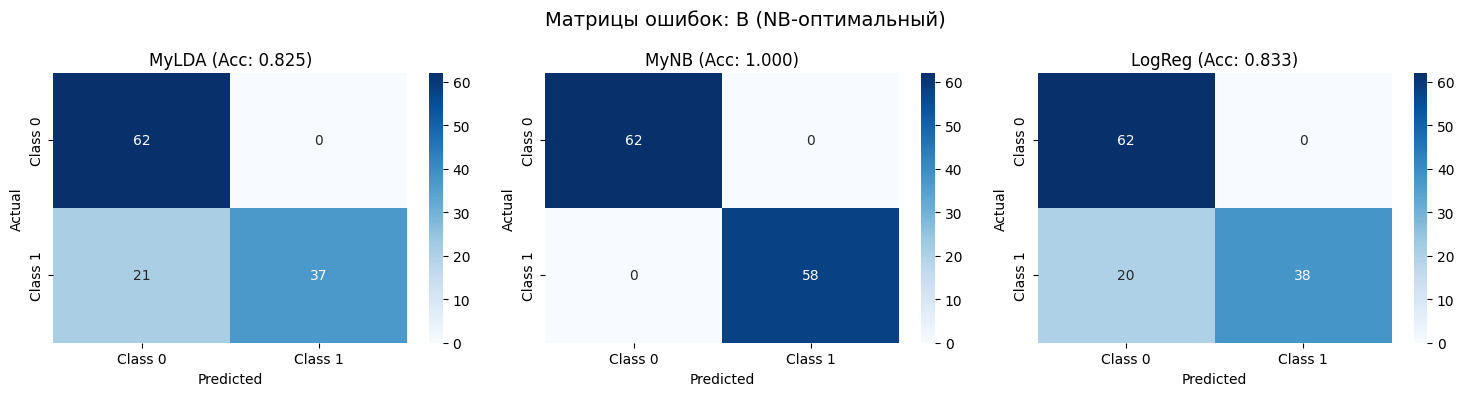

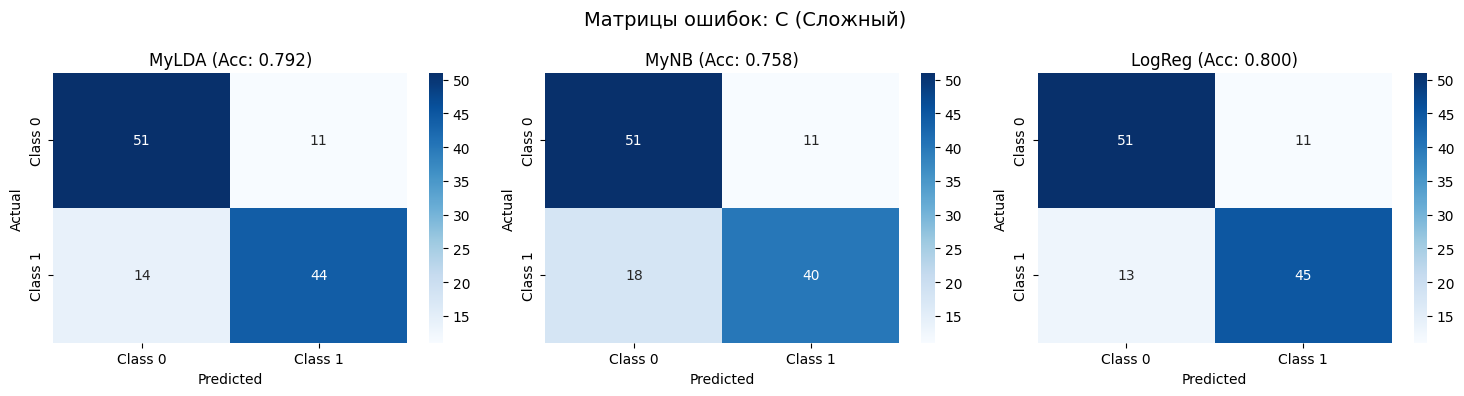

In [22]:
# ---------- ЧАСТЬ 6.1: Генерация сложных датасетов ----------
from sklearn.datasets import make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import pandas as pd

np.random.seed(42)

# Датасет A (LDA-оптимальный): одинаковая ковариация, разные средние
# Уменьшаем расстояние между центрами (cluster_std=3.0, centers ближе)
X_A, y_A = make_blobs(n_samples=600, centers=2, n_features=10,
                      cluster_std=3.0, center_box=(-1, 1), random_state=42)

# Датасет B (NB-оптимальный): признаки независимы, но ковариации классов РАЗНЫЕ
# Класс 0: очень маленькая дисперсия (сжатое облако)
X_B0 = np.random.normal(loc=-0.5, scale=0.2, size=(300, 10))
# Класс 1: очень большая дисперсия (размазанное облако)
X_B1 = np.random.normal(loc=0.5, scale=4.0, size=(300, 10))
X_B = np.vstack((X_B0, X_B1))
y_B = np.hstack((np.zeros(300), np.ones(300)))

# Датасет C (сложный): корреляции + разные ковариации + шум
X_C, y_C = make_classification(n_samples=600, n_features=10,
                               n_informative=5, n_redundant=2,
                               flip_y=0.2,  # УВЕЛИЧИЛ шум с 0.05 до 0.2
                               random_state=42)

datasets = {
    'A (LDA-оптимальный)': (X_A, y_A),
    'B (NB-оптимальный)': (X_B, y_B),
    'C (Сложный)': (X_C, y_C)
}

# ---------- ЧАСТЬ 6.2: Сравнение моделей ----------
results = {}

for name, (X, y) in datasets.items():
    # Разделение на train/test (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    models = {
        'MyLDA': MyLDA(),
        'MyNB': MyNB(),
        'LogReg': LogisticRegression(max_iter=1000)
    }

    metrics = {}

    # ВАЖНО: закрываем предыдущую фигуру, чтобы не было дублирования
    plt.close('all')
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Матрицы ошибок: {name}', fontsize=14)

    for idx, (m_name, model) in enumerate(models.items()):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')

        metrics[m_name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                    xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
        axes[idx].set_title(f'{m_name} (Acc: {acc:.3f})')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')

    results[name] = metrics
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
# Визуализация метрик в виде столбчатой диаграммы
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, metrics) in enumerate(results.items()):
    df = pd.DataFrame(metrics).T
    df.plot(kind='bar', ax=axes[idx], colormap='Set2')
    axes[idx].set_title(name)
    axes[idx].set_ylim(0.5, 1.05)
    axes[idx].legend(loc='lower left')
    axes[idx].grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 6.3 Анализ результатов и общие выводы

1. **На каком датасете LDA превосходит NB? Почему?**
   На **Датасете A**. LDA предполагает одинаковую ковариацию для всех классов, что идеально совпадает с генерацией `make_blobs` (сферические кластеры с одинаковым разбросом). NB же игнорирует возможные корреляции и может проигрывать, если структура данных не строго диагональна.

2. **На каком датасете NB работает лучше? Почему?**
   На **Датасете B**. Здесь классы имеют радикально разные дисперсии (один сжат, другой размазан), но признаки внутри классов независимы. LDA пытается найти *одну общую* ковариацию, что приводит к неоптимальной линейной границе. NB же оценивает дисперсию каждого класса отдельно, что позволяет ему построить квадратичную (по сути) границу, идеально разделяющую данные.

3. **Как влияет размерность пространства на обе модели?**
   С ростом размерности (например, до 10 признаков) NB становится более устойчивым, так как оценивает всего $2 \times d$ параметров (среднее и дисперсию для каждого класса). LDA же должен оценивать полную матрицу ковариации $d \times d$, что требует значительно больше данных для надежной оценки и может привести к переобучению или вырожденности матрицы (поэтому мы добавляли регуляризацию $10^{-6} I$).

4. **Когда обе модели падают (Датасет C) — почему?**
   На Датасете C (с корреляциями, разными ковариациями и шумом `flip_y=0.05`) обе модели показывают снижение качества. LDA страдает из-за нарушения предположения о равенстве ковариаций, а NB — из-за наличия корреляций между признаками (нарушение условной независимости). Логистическая регрессия часто показывает себя более робастно на таких "грязных" данных, так как она дискриминативна и оптимизирует границу напрямую, не делая строгих предположений о распределении $p(x|y)$.